--- RÉSULTATS DU MATCH DES PRÉDICTEURS ---
Modèle 1 (Via Proba) : Crowd = 1.60 * p^1.51
-> RMSE Proba = ± 8.04 % d'erreur moyenne

Modèle 2 (Via Gain)  : Crowd = 1.82 * exp(-0.0086 * Gain) + -0.44
-> RMSE Gain  = ± 10.21 % d'erreur moyenne

🏆 VERDICT : La Probabilité réelle reste le MEILLEUR prédicteur du comportement de la foule.


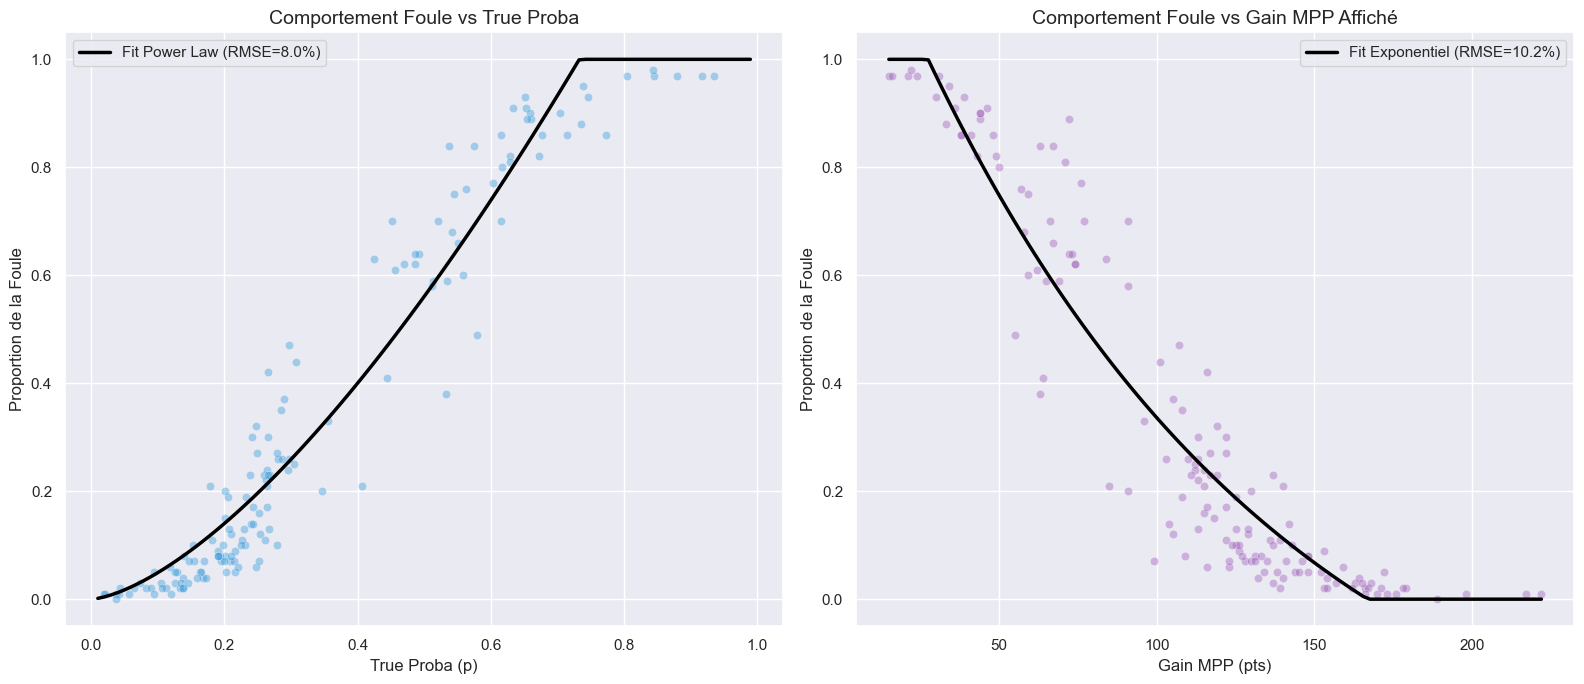

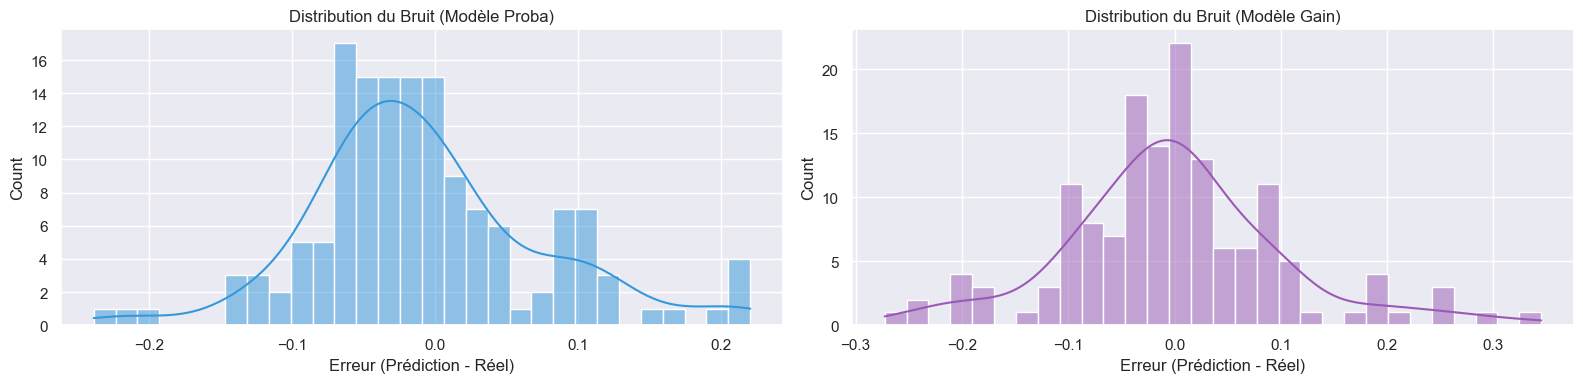

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from pathlib import Path
import sys

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [16, 7]
plt.rcParams['figure.dpi'] = 100

# Import de ton module core
sys.path.append(str(Path.cwd().parent))
from mpp_project.core import load_tournament_data

# --- 1. CHARGEMENT ET PRÉPARATION ---
data_path_csv = Path.cwd().parent / "data" / "CDM_2026.csv"
df, true_probas, mpp_gains, crowd_repartitions = load_tournament_data(data_path_csv)

X_probas = true_probas.flatten()
Y_gains = mpp_gains.flatten()
Y_crowd = crowd_repartitions.flatten()

# Filtrage global des données valides
valid_mask = (X_probas > 0) & (~np.isnan(X_probas)) & (~np.isnan(Y_gains))
X_probas = X_probas[valid_mask]
Y_gains = Y_gains[valid_mask]
Y_crowd = Y_crowd[valid_mask]

# --- 2. MODÉLISATION MATHÉMATIQUE (Le Match : Proba vs Gain) ---

# Modèle 1 : La Foule selon la Probabilité (Power Law)
def func_crowd_proba(p, a, b):
    return a * (p ** b)

# On garde ton idée d'exclure p > 0.8 pour l'apprentissage
mask_proba_fit = X_probas <= 0.8
popt_proba, _ = curve_fit(func_crowd_proba, X_probas[mask_proba_fit] + 1e-5, Y_crowd[mask_proba_fit])


# Modèle 2 : La Foule selon le Gain MPP (Décroissance Exponentielle)
# Hypothèse : Un gain très élevé repousse la foule de manière exponentielle
def func_crowd_gain(g, a, b, c):
    return a * np.exp(-b * g) + c

# On donne un point de départ (p0) pour aider l'algorithme à converger sur l'exponentielle
popt_gain, _ = curve_fit(func_crowd_gain, Y_gains, Y_crowd, p0=[1.0, 0.05, 0.0], maxfev=5000)


# Fonctions de prédiction avec plafonnement physique (entre 0% et 100%)
def predict_crowd_proba(p):
    return min(1.0, max(0.0, func_crowd_proba(p, *popt_proba)))

def predict_crowd_gain(g):
    return min(1.0, max(0.0, func_crowd_gain(g, *popt_gain)))

vec_pred_proba = np.vectorize(predict_crowd_proba)
vec_pred_gain = np.vectorize(predict_crowd_gain)

# --- 3. CALCUL DE L'ERREUR (Le Juge de Paix) ---
rmse_proba = np.sqrt(np.mean((Y_crowd - vec_pred_proba(X_probas))**2))
rmse_gain = np.sqrt(np.mean((Y_crowd - vec_pred_gain(Y_gains))**2))

print("--- RÉSULTATS DU MATCH DES PRÉDICTEURS ---")
print(f"Modèle 1 (Via Proba) : Crowd = {popt_proba[0]:.2f} * p^{popt_proba[1]:.2f}")
print(f"-> RMSE Proba = ± {rmse_proba*100:.2f} % d'erreur moyenne\n")

print(f"Modèle 2 (Via Gain)  : Crowd = {popt_gain[0]:.2f} * exp(-{popt_gain[1]:.4f} * Gain) + {popt_gain[2]:.2f}")
print(f"-> RMSE Gain  = ± {rmse_gain*100:.2f} % d'erreur moyenne\n")

if rmse_gain < rmse_proba:
    print("🏆 VERDICT : Le Gain MPP est un MEILLEUR prédicteur du comportement de la foule que la Proba !")
else:
    print("🏆 VERDICT : La Probabilité réelle reste le MEILLEUR prédicteur du comportement de la foule.")

# --- 4. AFFICHAGE DES RÉSULTATS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : Crowd vs Proba
x_line_p = np.linspace(0.01, 0.99, 100)
y_line_p = vec_pred_proba(x_line_p)

sns.scatterplot(x=X_probas, y=Y_crowd, alpha=0.4, color="#3498db", ax=axes[0])
axes[0].plot(x_line_p, y_line_p, color="black", linewidth=2.5, label=f"Fit Power Law (RMSE={rmse_proba*100:.1f}%)")
axes[0].set_title("Comportement Foule vs True Proba", fontsize=14)
axes[0].set_xlabel("True Proba (p)")
axes[0].set_ylabel("Proportion de la Foule")
axes[0].legend()

# Graphique 2 : Crowd vs Gain
# On crée une ligne de X pour les gains (de 10 à la valeur max observée)
x_line_g = np.linspace(min(Y_gains), max(Y_gains), 100)
y_line_g = vec_pred_gain(x_line_g)

sns.scatterplot(x=Y_gains, y=Y_crowd, alpha=0.4, color="#9b59b6", ax=axes[1])
axes[1].plot(x_line_g, y_line_g, color="black", linewidth=2.5, label=f"Fit Exponentiel (RMSE={rmse_gain*100:.1f}%)")
axes[1].set_title("Comportement Foule vs Gain MPP Affiché", fontsize=14)
axes[1].set_xlabel("Gain MPP (pts)")
axes[1].set_ylabel("Proportion de la Foule")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 5. ANALYSE DES RÉSIDUS (Bruit visuel) ---
# Afficher l'erreur pour voir si elle est bien distribuée de façon gaussienne
fig, axes_res = plt.subplots(1, 2, figsize=(16, 4))
residus_proba = Y_crowd - vec_pred_proba(X_probas)
residus_gain = Y_crowd - vec_pred_gain(Y_gains)

sns.histplot(residus_proba, bins=30, kde=True, color="#3498db", ax=axes_res[0])
axes_res[0].set_title("Distribution du Bruit (Modèle Proba)")
axes_res[0].set_xlabel("Erreur (Prédiction - Réel)")

sns.histplot(residus_gain, bins=30, kde=True, color="#9b59b6", ax=axes_res[1])
axes_res[1].set_title("Distribution du Bruit (Modèle Gain)")
axes_res[1].set_xlabel("Erreur (Prédiction - Réel)")

plt.tight_layout()
plt.show()

--- MODÈLE MULTINOMIAL (SOFTMAX + PLANCHER) ---
Paramètre de Sur-réaction (Beta) = 2.237
Plancher Incompressible (Epsilon) = 0.90 %

Performances :
-> MAPE (Erreur Relative) = ± 24.7 %
-> RMSE (Erreur Absolue)  = ± 8.3 %

🎯 TON INTUITION EST VALIDÉE ! L'algorithme a trouvé un plancher naturel de 0.90%.


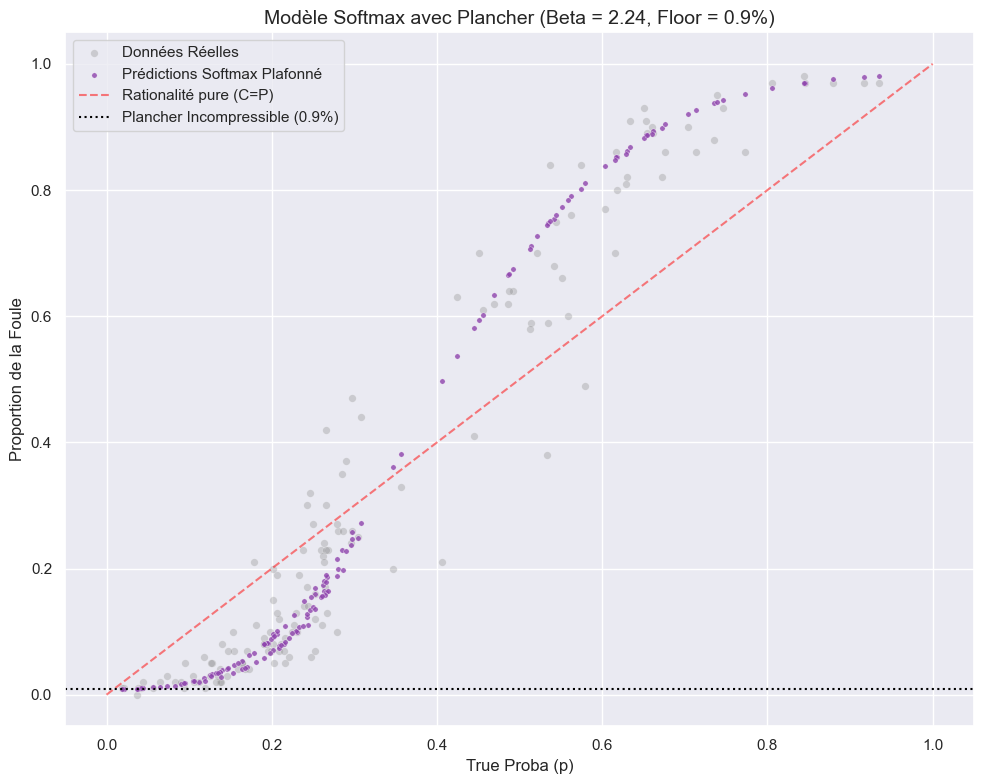


--- TEST SUR LE MATCH DÉSÉQUILIBRÉ ---
Probas : (0.8, 0.15, 0.05) -> Foule estimée : 1: 95.8% | N: 3.1% | 2: 1.1%


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from pathlib import Path
import sys

# Configuration visuelle
%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Import de ton module core
sys.path.append(str(Path.cwd().parent))
from mpp_project.core import load_tournament_data

# --- 1. CHARGEMENT ET PRÉPARATION ---
data_path_csv = Path.cwd().parent / "data" / "CDM_2026.csv"
df, true_probas, mpp_gains, crowd_repartitions = load_tournament_data(data_path_csv)

valid_mask = (true_probas.sum(axis=1) > 0) & (~np.isnan(true_probas).any(axis=1)) & (~np.isnan(crowd_repartitions).any(axis=1))
P = true_probas[valid_mask]
C = crowd_repartitions[valid_mask]

# --- 2. MODÉLISATION MATHÉMATIQUE (Softmax avec Plancher) ---

def softmax_with_floor(probas, beta, eps):
    """
    Modèle de choix multinomial avec un "bruit" minimum incompressible (eps).
    """
    utilities = np.power(probas, beta)
    sum_utilities = np.sum(utilities, axis=1, keepdims=True)
    softmax_part = utilities / sum_utilities
    
    # On garantit 'eps' à tout le monde, on distribue le reste via Softmax
    return eps + (1.0 - 3.0 * eps) * softmax_part

# Fonction de coût (MAPE)
def cost_function(params):
    beta, eps = params
    C_pred = softmax_with_floor(P, beta, eps)
    mape = np.mean(np.abs((C - C_pred) / (C + 0.01)))
    return mape

# Optimisation (Beta entre 0.1 et 5.0 | Eps entre 0% et 5%)
initial_guess = [2.0, 0.005] 
result = minimize(cost_function, initial_guess, bounds=[(0.1, 5.0), (0.0, 0.05)])
best_beta, best_eps = result.x

# --- 3. ÉVALUATION ---
C_pred = softmax_with_floor(P, best_beta, best_eps)

mape_global = np.mean(np.abs((C - C_pred) / (C + 0.01)))
rmse_global = np.sqrt(np.mean((C.flatten() - C_pred.flatten())**2))

print("--- MODÈLE MULTINOMIAL (SOFTMAX + PLANCHER) ---")
print(f"Paramètre de Sur-réaction (Beta) = {best_beta:.3f}")
print(f"Plancher Incompressible (Epsilon) = {best_eps*100:.2f} %")
print(f"\nPerformances :")
print(f"-> MAPE (Erreur Relative) = ± {mape_global*100:.1f} %")
print(f"-> RMSE (Erreur Absolue)  = ± {rmse_global*100:.1f} %")

if best_eps > 0.001:
    print(f"\n🎯 TON INTUITION EST VALIDÉE ! L'algorithme a trouvé un plancher naturel de {best_eps*100:.2f}%.")

# --- 4. AFFICHAGE DES RÉSULTATS ---
fig, ax = plt.subplots(figsize=(10, 8))

C_flat = C.flatten()
C_pred_flat = C_pred.flatten()
P_flat = P.flatten()

sns.scatterplot(x=P_flat, y=C_flat, alpha=0.3, color="gray", label="Données Réelles", s=30)
sns.scatterplot(x=P_flat, y=C_pred_flat, alpha=0.8, color="#8e44ad", label="Prédictions Softmax Plafonné", s=15)

ax.plot([0, 1], [0, 1], color="red", linestyle="--", alpha=0.5, label="Rationalité pure (C=P)")

# Ajout de la ligne d'horizon du plancher
ax.axhline(best_eps, color="black", linestyle=":", label=f"Plancher Incompressible ({best_eps*100:.1f}%)")

ax.set_title(f"Modèle Softmax avec Plancher (Beta = {best_beta:.2f}, Floor = {best_eps*100:.1f}%)", fontsize=14)
ax.set_xlabel("True Proba (p)")
ax.set_ylabel("Proportion de la Foule")
ax.legend()

plt.tight_layout()
plt.show()

# --- 5. TEST PRATIQUE ---
def estimate_crowd_3D(p1, pN, p2, beta=best_beta, eps=best_eps):
    u1, uN, u2 = p1**beta, pN**beta, p2**beta
    somme = u1 + uN + u2
    c1 = eps + (1 - 3*eps) * (u1 / somme)
    cN = eps + (1 - 3*eps) * (uN / somme)
    c2 = eps + (1 - 3*eps) * (u2 / somme)
    return c1, cN, c2

print("\n--- TEST SUR LE MATCH DÉSÉQUILIBRÉ ---")
test_match2 = (0.80, 0.15, 0.05)
c1_2, cN_2, c2_2 = estimate_crowd_3D(*test_match2)
print(f"Probas : {test_match2} -> Foule estimée : 1: {c1_2*100:.1f}% | N: {cN_2*100:.1f}% | 2: {c2_2*100:.1f}%")